<a href="https://colab.research.google.com/github/Shashank-Karanam/6thSem-ML-Lab/blob/main/1BM23CS312_Lab_8_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Build a Random Forest (RF) classifier to classify IRIS flower dataset

Measure prediction score using default n_estimators (10).

Now fine tune your model by changing number of trees in your classifer and identify what best score you can get using how
many trees

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
df = pd.read_csv('iris.csv')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
X = df.drop(columns=['species'])
y = df['species']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
rf = RandomForestClassifier(n_estimators=10, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10, random_state=42)

Accuracy (10 trees): 0.9666666666666667


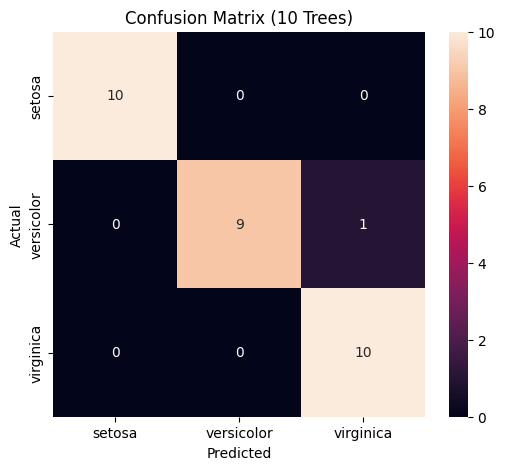

In [ ]:
y_pred = rf.predict(X_test)

print("Accuracy (10 trees):", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

labels = sorted(y.unique())

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (10 Trees)")
plt.show()

In [ ]:
tree_counts = [10, 20, 50, 100, 150, 200]
scores = []

for n in tree_counts:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    scores.append(acc)
    print(f"Trees: {n} → Accuracy: {acc}")

Trees: 10 → Accuracy: 0.9666666666666667
Trees: 20 → Accuracy: 0.9333333333333333
Trees: 50 → Accuracy: 0.9
Trees: 100 → Accuracy: 0.9
Trees: 150 → Accuracy: 0.9
Trees: 200 → Accuracy: 0.9


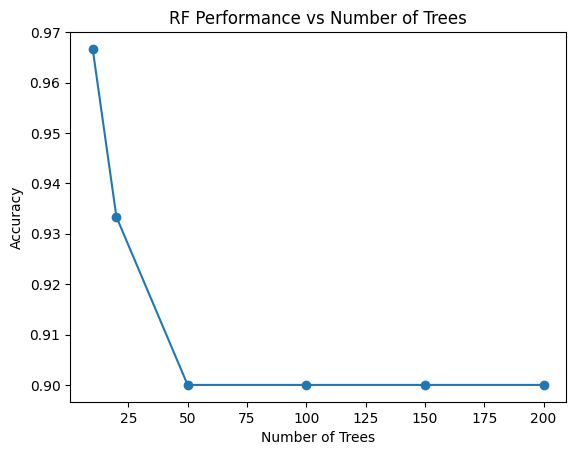

In [ ]:
plt.plot(tree_counts, scores, marker='o')
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("RF Performance vs Number of Trees")
plt.show()

Best number of trees: 10
Best Accuracy: 0.9666666666666667


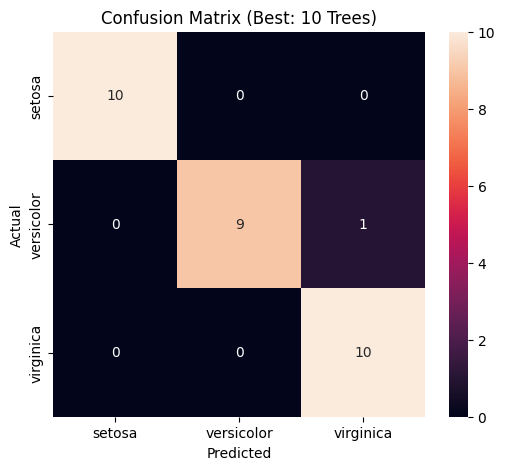

In [ ]:
best_n = tree_counts[scores.index(max(scores))]
print("Best number of trees:", best_n)

best_model = RandomForestClassifier(n_estimators=best_n, random_state=42)
best_model.fit(X_train, y_train)

y_pred_best = best_model.predict(X_test)

print("Best Accuracy:", accuracy_score(y_test, y_pred_best))

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)

plt.title(f"Confusion Matrix (Best: {best_n} Trees)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

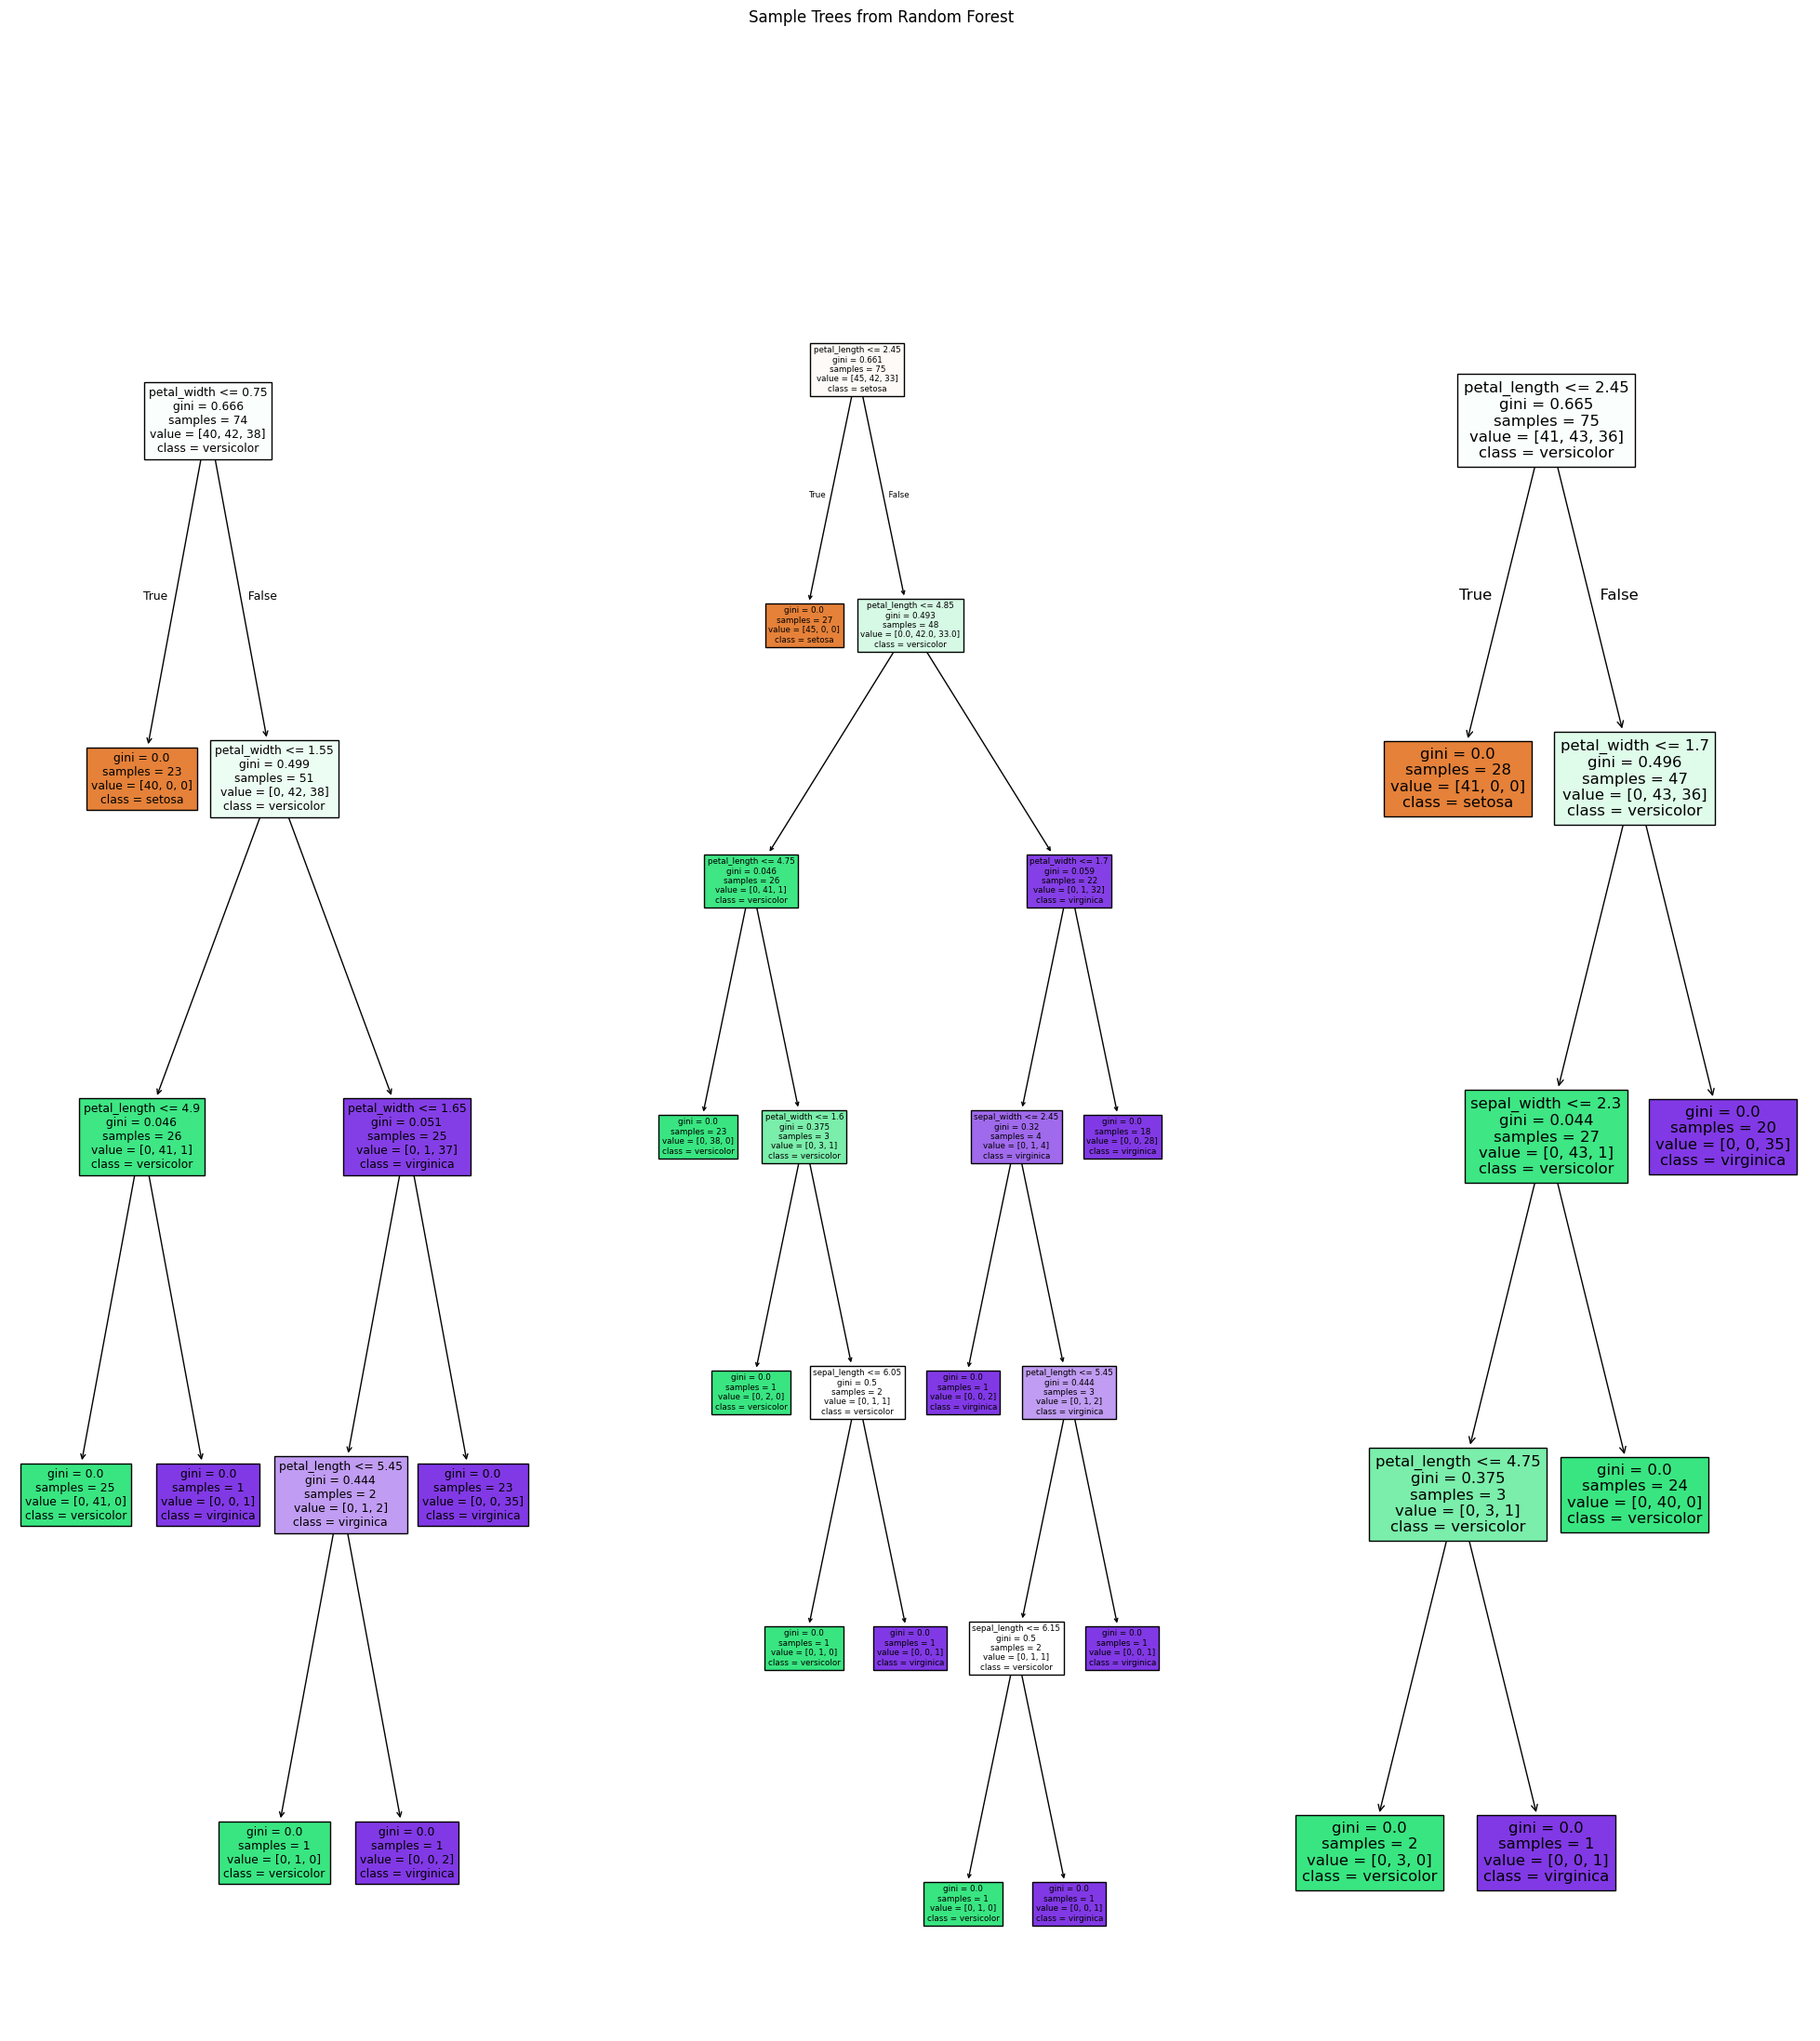

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(25,25))

# Plot first 3 trees
for i in range(3):
    plt.subplot(1, 3, i+1)
    plot_tree(rf.estimators_[i],
              feature_names=X.columns,
              class_names=rf.classes_,
              filled=True)

plt.suptitle("Sample Trees from Random Forest")
plt.show()